In [1]:
import torch

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU: Tesla T4


The above code ensures that we took GPU into use

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Mounted the drive into the Colab

In [ ]:
import os

drive_path = "/content/drive/MyDrive"

print(os.listdir(drive_path))

Locates the drive path for the dataset uploaded in the drive

In [6]:
!unzip "/content/drive/MyDrive/MRI_Project/output_slices.zip" -d "/content/drive/MyDrive/MRI_Project/"

Archive:  /content/drive/MyDrive/MRI_Project/output_slices.zip
   creating: /content/drive/MyDrive/MRI_Project/output_slices/
  inflating: /content/drive/MyDrive/MRI_Project/output_slices/slice_0.png  
  inflating: /content/drive/MyDrive/MRI_Project/output_slices/slice_1.png  
  inflating: /content/drive/MyDrive/MRI_Project/output_slices/slice_10.png  
  inflating: /content/drive/MyDrive/MRI_Project/output_slices/slice_100.png  
  inflating: /content/drive/MyDrive/MRI_Project/output_slices/slice_101.png  
  inflating: /content/drive/MyDrive/MRI_Project/output_slices/slice_102.png  
  inflating: /content/drive/MyDrive/MRI_Project/output_slices/slice_103.png  
  inflating: /content/drive/MyDrive/MRI_Project/output_slices/slice_104.png  
  inflating: /content/drive/MyDrive/MRI_Project/output_slices/slice_105.png  
  inflating: /content/drive/MyDrive/MRI_Project/output_slices/slice_106.png  
  inflating: /content/drive/MyDrive/MRI_Project/output_slices/slice_107.png  
  inflating: /content

Unzip the zipped dataset into the project folder

In [8]:
import os

dataset_path = "/content/drive/MyDrive/MRI_Project/output_slices"

print(os.listdir(dataset_path)[:10])

['slice_0.png', 'slice_1.png', 'slice_10.png', 'slice_100.png', 'slice_101.png', 'slice_102.png', 'slice_103.png', 'slice_104.png', 'slice_105.png', 'slice_106.png']


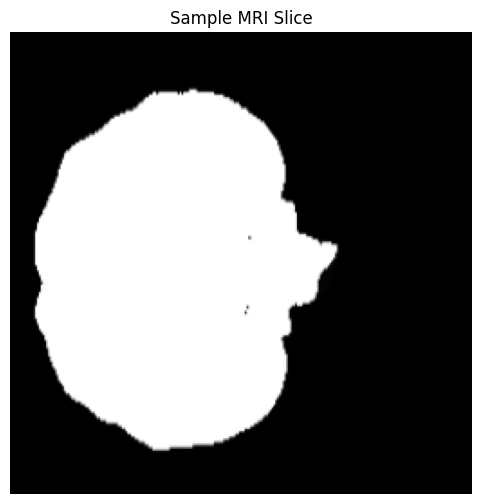

In [9]:
from PIL import Image
import matplotlib.pyplot as plt
import os

sample_image = os.path.join(dataset_path, os.listdir(dataset_path)[0])

img = Image.open(sample_image)

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title("Sample MRI Slice")
plt.show()

Sample MRI image.
Now, we have preprocessed the data are ready for the training process.

In [10]:
!pip install diffusers
!pip install transformers
!pip install accelerate

The above installs the libraries required and they're imported below

In [11]:
import torch
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from PIL import Image

import os
import matplotlib.pyplot as plt

from diffusers import UNet2DModel
from diffusers import DDPMScheduler

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [13]:
class MRIDataset(Dataset):

    def __init__(self, folder_path):

        self.folder_path = folder_path

        self.image_files = [
            os.path.join(folder_path, file)
            for file in os.listdir(folder_path)
            if file.endswith(".png")
        ]

        self.transform = transforms.Compose([
            transforms.Grayscale(),
            transforms.Resize((128, 128)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):

        image = Image.open(
            self.image_files[idx]
        )

        image = self.transform(image)

        return image

Loads MRI PNG images
->
Converts to grayscale
->
Resizes to 128×128
->
Converts to tensor
->
Normalizes pixel values

Dataset Size: 737


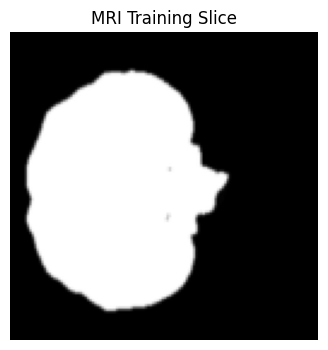

In [15]:
dataset_path = "/content/drive/MyDrive/MRI_Project/output_slices"

dataset = MRIDataset(dataset_path)

dataloader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)

print("Dataset Size:", len(dataset))



sample = dataset[0]

plt.figure(figsize=(4,4))

plt.imshow(
    sample.squeeze(),
    cmap="gray"
)

plt.axis("off")
plt.title("MRI Training Slice")

plt.show()

The above code crates a datadownloader and visualizes a training image

In [16]:
model = UNet2DModel(

    sample_size=128,

    in_channels=1,
    out_channels=1,

    layers_per_block=2,

    block_out_channels=(64, 128, 128),

    down_block_types=(
        "DownBlock2D",
        "AttnDownBlock2D",
        "DownBlock2D",
    ),

    up_block_types=(
        "UpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
    ),
)

model = model.to("cuda")

The above created a U-net architecture which: Noisy MRI ->
Predict Noise
->
Recover Cleaner MRI

In [17]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4
)


noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000
)

Creates noise scheduler and optimizer


THE TRAINING LOOP

In [18]:
epochs = 5

model.train()

for epoch in range(epochs):

    print(f"\nEpoch {epoch+1}")

    for step, images in enumerate(dataloader):

        images = images.to("cuda")

        # RANDOM NOISE
        noise = torch.randn_like(images)

        batch_size = images.shape[0]

        # RANDOM TIMESTEPS
        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (batch_size,),
            device=images.device
        ).long()

        # ADD NOISE
        noisy_images = noise_scheduler.add_noise(
            images,
            noise,
            timesteps
        )

        # PREDICT NOISE
        noise_pred = model(
            noisy_images,
            timesteps
        ).sample

        # LOSS
        loss = F.mse_loss(
            noise_pred,
            noise
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        if step % 10 == 0:
            print(
                f"Step {step} | Loss: {loss.item():.4f}"
            )


Epoch 1
Step 0 | Loss: 1.2147
Step 10 | Loss: 0.0947
Step 20 | Loss: 0.0530
Step 30 | Loss: 0.1053
Step 40 | Loss: 0.0407
Step 50 | Loss: 0.0528
Step 60 | Loss: 0.0246
Step 70 | Loss: 0.1461
Step 80 | Loss: 0.0543
Step 90 | Loss: 0.0270

Epoch 2
Step 0 | Loss: 0.0426
Step 10 | Loss: 0.0253
Step 20 | Loss: 0.0564
Step 30 | Loss: 0.0282
Step 40 | Loss: 0.0364
Step 50 | Loss: 0.0331
Step 60 | Loss: 0.0203
Step 70 | Loss: 0.1235
Step 80 | Loss: 0.0209
Step 90 | Loss: 0.0504

Epoch 3
Step 0 | Loss: 0.0320
Step 10 | Loss: 0.0312
Step 20 | Loss: 0.0173
Step 30 | Loss: 0.0151
Step 40 | Loss: 0.0750
Step 50 | Loss: 0.0163
Step 60 | Loss: 0.0358
Step 70 | Loss: 0.0107
Step 80 | Loss: 0.0253
Step 90 | Loss: 0.0178

Epoch 4
Step 0 | Loss: 0.0313
Step 10 | Loss: 0.0953
Step 20 | Loss: 0.0331
Step 30 | Loss: 0.0128
Step 40 | Loss: 0.0524
Step 50 | Loss: 0.0140
Step 60 | Loss: 0.0337
Step 70 | Loss: 0.0099
Step 80 | Loss: 0.0064
Step 90 | Loss: 0.0118

Epoch 5
Step 0 | Loss: 0.0185
Step 10 | Loss: 0

Now, the model is trained and we move to the evaluation part. We perform the Reverse Diffusion process.


In [19]:
model.eval()

import torch
import matplotlib.pyplot as plt

# START FROM RANDOM NOISE
sample = torch.randn(
    (1, 1, 128, 128)
).to("cuda")

# SET TIMESTEPS
noise_scheduler.set_timesteps(1000)

# REVERSE DIFFUSION
for timestep in noise_scheduler.timesteps:

    with torch.no_grad():

        noise_pred = model(
            sample,
            timestep
        ).sample

    sample = noise_scheduler.step(
        noise_pred,
        timestep,
        sample
    ).prev_sample

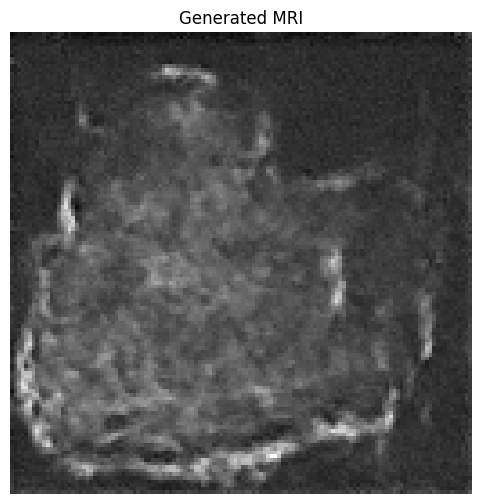

In [20]:
generated_image = sample.squeeze().cpu().numpy()

# DENORMALIZE
generated_image = (
    generated_image * 0.5
) + 0.5

plt.figure(figsize=(6,6))

plt.imshow(
    generated_image,
    cmap="gray"
)

plt.title("Generated MRI")
plt.axis("off")

plt.show()

# **This model generates a human brain MRI scan from completely random noisy image.**